In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('results_2025-07-24-10-39_day_20230612_170.csv')

In [4]:
num_train_days = df['train_day'].nunique()
print(f"Number of unique train_days: {num_train_days}")

Number of unique train_days: 283


In [5]:
df['relative_days'] = (pd.to_datetime(df['test_day'], format='%Y%m%d') - pd.to_datetime(df['train_day'], format='%Y%m%d')).dt.days

In [6]:
df

,train_day,train_duration,test_day,r_mean,r2,mse_mean,relative_days
0,20200211,1,20200127,0.616541,0.353742,0.011062,-15
1,20200211,1,20200130,0.655359,0.397139,0.007662,-12
2,20200211,1,20200204,0.671074,0.360725,0.006788,-7
3,20200211,1,20200205,0.554533,0.257568,0.008306,-6
4,20200211,1,20200206,0.643000,0.334300,0.007409,-5
...,...,...,...,...,...,...,...
271265,20230612,5,20230616,0.704660,0.477173,0.012989,4
271266,20230612,5,20230619,0.672185,0.456822,0.019599,7
271267,20230612,5,20230620,0.714102,0.498157,0.010811,8
271268,20230612,5,20230621,0.753844,0.544939,0.009365,9


In [7]:
df_filtered = df[(df['relative_days'] >= -185) & (df['relative_days'] <= 180)]
df_filtered

,train_day,train_duration,test_day,r_mean,r2,mse_mean,relative_days
0,20200211,1,20200127,0.616541,0.353742,0.011062,-15
1,20200211,1,20200130,0.655359,0.397139,0.007662,-12
2,20200211,1,20200204,0.671074,0.360725,0.006788,-7
3,20200211,1,20200205,0.554533,0.257568,0.008306,-6
4,20200211,1,20200206,0.643000,0.334300,0.007409,-5
...,...,...,...,...,...,...,...
271265,20230612,5,20230616,0.704660,0.477173,0.012989,4
271266,20230612,5,20230619,0.672185,0.456822,0.019599,7
271267,20230612,5,20230620,0.714102,0.498157,0.010811,8
271268,20230612,5,20230621,0.753844,0.544939,0.009365,9


In [8]:
grouped_df = df_filtered.groupby(['train_duration', 'relative_days']).agg({
    'r_mean': 'mean',
    'r2': ['mean', 'sem'],
    'mse_mean': 'mean'
}).reset_index()
grouped_df.columns = ['train_duration', 'relative_days', 'r_mean', 'r2', 'r2_sem', 'mse_mean']
grouped_df

,train_duration,relative_days,r_mean,r2,r2_sem,mse_mean
0,1,-185,0.422067,0.064550,0.022466,0.017893
1,1,-184,0.450126,0.039100,0.030884,0.017506
2,1,-183,0.442046,0.036184,0.028866,0.017710
3,1,-182,0.442276,0.066358,0.020755,0.017288
4,1,-181,0.413325,0.041985,0.027702,0.019012
...,...,...,...,...,...,...
1825,5,176,0.512005,0.200329,0.024071,0.017563
1826,5,177,0.518757,0.197508,0.026429,0.017268
1827,5,178,0.499551,0.188840,0.022342,0.017133
1828,5,179,0.531462,0.211587,0.022004,0.016174


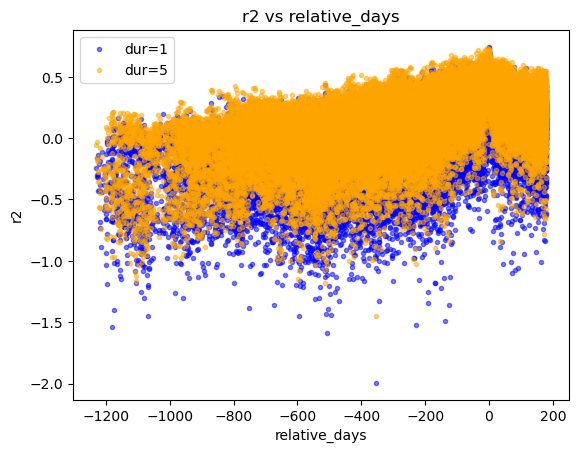

In [8]:
durs = [1,2,3,4,5]
durs = [1,5]
colours = ['blue', 'orange', 'green', 'red', 'purple']
colours = ['blue', 'orange']
for i, dur in enumerate(durs):
    dur_df = df[df['train_duration'] == dur]
    plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'dur={dur}', color=colours[i], alpha = 0.5)
plt.xlabel('relative_days')
plt.ylabel('r2')
plt.title('r2 vs relative_days')
plt.legend()
plt.show()


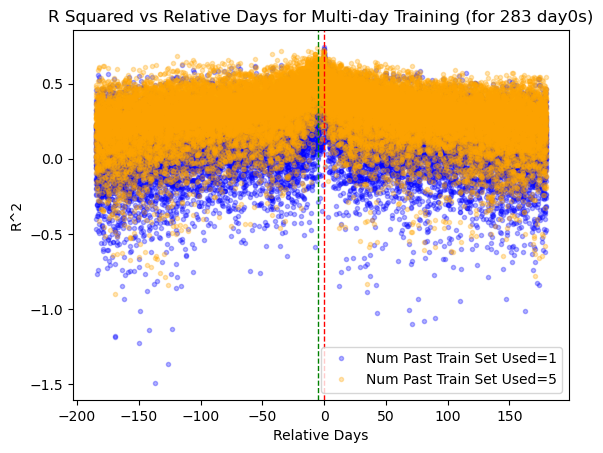

In [9]:
durs = [1,2,3,4,5]
durs = [1,5]
colours = ['blue', 'orange', 'green', 'red', 'purple']
colours = ['blue', 'orange']
for i, dur in enumerate(durs):
    dur_df = df_filtered[df_filtered['train_duration'] == dur]
    plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
plt.xlabel('Relative Days')
plt.ylabel('R^2')
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.axvline(-5, color='green', linestyle='--', linewidth=1)
plt.legend()
plt.show()


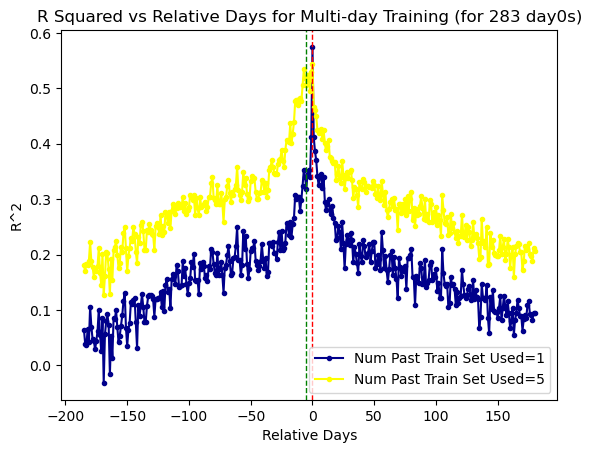

In [10]:
durs = [1,2,3,4,5]
durs = [1,5]
colours = ['blue', 'orange', 'green', 'red', 'purple']
colours = ['blue', 'orange']
another_colours = ['darkblue', 'yellow']
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    plt.plot(dur_df2['relative_days'], dur_df2['r2'],'.-', label=f'Num Past Train Set Used={dur}', color=another_colours[i], alpha = 1.0)
plt.xlabel('Relative Days')
plt.ylabel('R^2')
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.axvline(-5, color='green', linestyle='--', linewidth=1)
plt.legend()
plt.show()


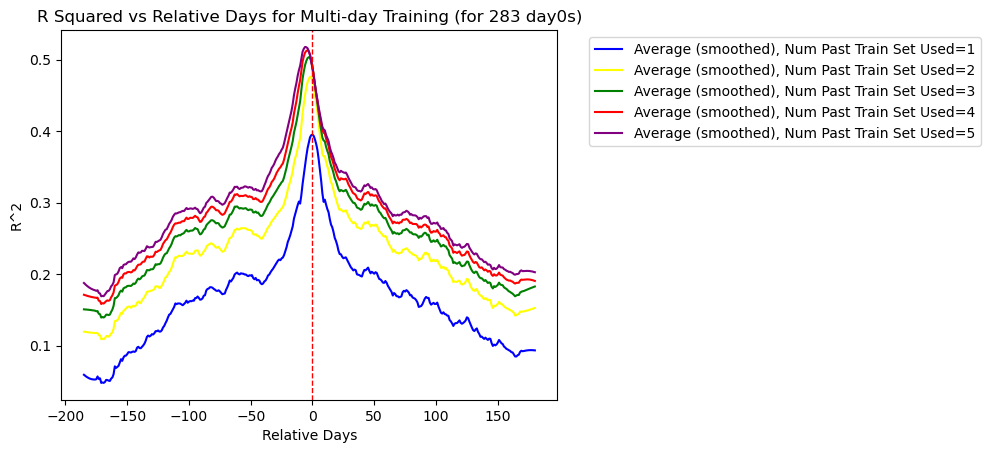

In [ ]:
from scipy.signal import savgol_filter


durs = [1,2,3,4,5]
#durs = [1,5]
colours = ['darkblue', 'orange', 'darkgreen', 'darkred', 'black']
#colours = ['darkblue', 'orange']
another_colours = ['blue', 'yellow', 'green', 'red', 'purple']
#another_colours = ['blue', 'yellow']
# for i, dur in enumerate(durs):
#     dur_df = df_filtered[df_filtered['train_duration'] == dur]
#     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    dur_df2_sorted = dur_df2.sort_values('relative_days')
    r2_smooth = savgol_filter(dur_df2_sorted['r2'], window_length=20, polyorder=2)
    plt.plot(dur_df2_sorted['relative_days'], r2_smooth, '-', label=f'Average (smoothed), Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)
plt.xlabel('Relative Days')
plt.ylabel('R^2')
#plt.gcf().set_size_inches(20, 60)
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


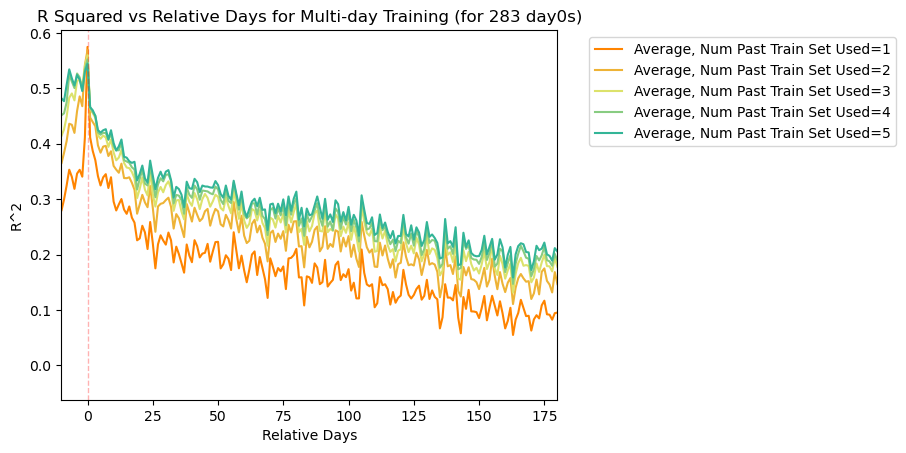

In [12]:
durs = [1,2,3,4,5]
#durs = [1,2]
colours = ['#FF8400', '#EEB336', '#DCE26B', '#88CC81', '#33B597']
#colours = ['darkblue', 'orange']
another_colours = ['#FF8400', '#EEB336', '#DCE26B', '#88CC81', '#33B597']
#another_colours = ['blue', 'yellow']
# for i, dur in enumerate(durs):
#     dur_df = df_filtered[df_filtered['train_duration'] == dur]
#     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    plt.plot(dur_df2_sorted['relative_days'], dur_df2['r2'], '-', label=f'Average, Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)
plt.xlabel('Relative Days')
plt.ylabel('R^2')
#plt.gcf().set_size_inches(20, 60)
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha = 0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim((-10,180))
plt.savefig('multidayPlot.pdf', bbox_inches='tight')
plt.show()


Exp Decay Fit Parameters: [ 0.26291348 -0.02110392  0.10267552]
Exp Decay Fit Covariance: [[ 7.96039155e-05 -3.10807149e-06 -1.15430732e-05]
 [-3.10807149e-06  3.58379056e-06 -9.63910233e-06]
 [-1.15430732e-05 -9.63910233e-06  3.62026594e-05]]
Exp Decay Fit Parameters: [ 0.2540007  -0.01191568  0.17530203]
Exp Decay Fit Covariance: [[ 7.62537194e-05  7.06155332e-06 -7.56550432e-05]
 [ 7.06155332e-06  1.50232576e-06 -1.23165545e-05]
 [-7.56550432e-05 -1.23165545e-05  1.10942912e-04]]


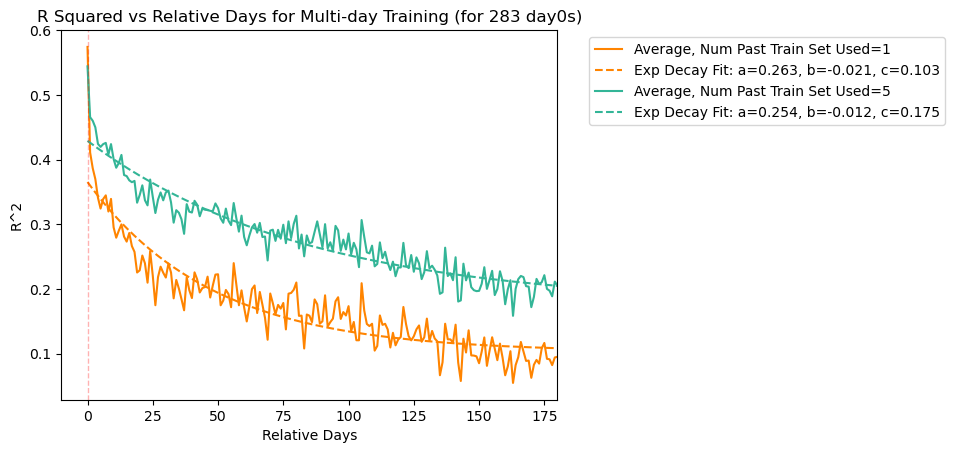

In [13]:
from scipy.optimize import curve_fit
from scipy.io import savemat

durs = [1,5]
#durs = [1,2]
colours = ['#FF8400', '#33B597']
#colours = ['darkblue', 'orange']
another_colours = ['#FF8400', '#33B597']
#another_colours = ['blue', 'yellow']
# for i, dur in enumerate(durs):
#     dur_df = df_filtered[df_filtered['train_duration'] == dur]
#     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    
    def double_exponential(x, a, b, c, d):
        return a * np.exp(b * x) + c * np.exp(d * x)

    xdata = dur_df2_sorted['relative_days'].values
    ydata = dur_df2['r2'].values
    mask = (xdata >= 0) & (xdata <= 180)
    xdata_fit = xdata[mask]
    ydata_fit = ydata[mask]
    plt.plot(xdata_fit, ydata_fit, '-', label=f'Average, Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)
    def exp_decay(x, a, b, c):
        return a * np.exp(b * x) + c

    popt_exp, pcov_exp = curve_fit(exp_decay, xdata_fit, ydata_fit, p0=(1, -0.01, 0.1))
    yfit_exp = exp_decay(xdata_fit, *popt_exp)
    plt.plot(xdata_fit, yfit_exp, '--', color=colours[i], label=f'Exp Decay Fit: a={popt_exp[0]:.3f}, b={popt_exp[1]:.3f}, c={popt_exp[2]:.3f}')
    print("Exp Decay Fit Parameters:", popt_exp)
    print("Exp Decay Fit Covariance:", pcov_exp)
    savemat(f'xdata_ydata_dur{dur}.mat', {'xdata': xdata, 'ydata': ydata})
plt.xlabel('Relative Days')
plt.ylabel('R^2')
#plt.gcf().set_size_inches(20, 60)
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha = 0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim((-10,180))
plt.savefig('multidayPlot.pdf', bbox_inches='tight')
plt.show()


Exp Decay Fit Parameters: [ 0.26223634 -0.12784267  0.22088172]
Exp Decay Fit Covariance: [[ 3.90047778e-04 -4.79982122e-05 -8.05098647e-05]
 [-4.79982122e-05  6.44222256e-04 -2.87270354e-04]
 [-8.05098647e-05 -2.87270354e-04  1.83338610e-04]]
Exp Decay Fit Parameters: [ 0.17482411 -0.09298904  0.32720865]
Exp Decay Fit Covariance: [[ 1.33176328e-04  6.94455170e-05 -8.07438088e-05]
 [ 6.94455170e-05  3.47828916e-04 -1.99477228e-04]
 [-8.07438088e-05 -1.99477228e-04  1.37006510e-04]]


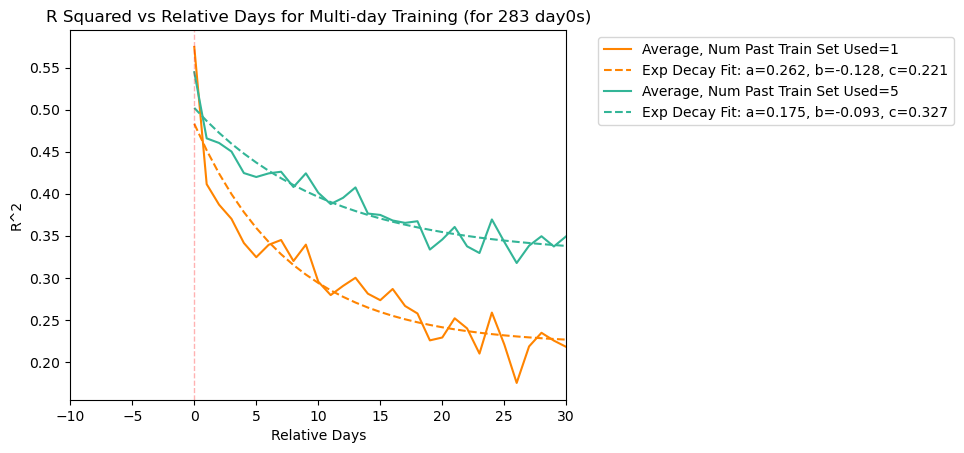

In [14]:
from scipy.optimize import curve_fit

durs = [1,5]
#durs = [1,2]
colours = ['#FF8400', '#33B597']
#colours = ['darkblue', 'orange']
another_colours = ['#FF8400', '#33B597']
#another_colours = ['blue', 'yellow']
# for i, dur in enumerate(durs):
#     dur_df = df_filtered[df_filtered['train_duration'] == dur]
#     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    
    def double_exponential(x, a, b, c, d):
        return a * np.exp(b * x) + c * np.exp(d * x)

    xdata = dur_df2_sorted['relative_days'].values
    ydata = dur_df2['r2'].values
    mask = (xdata >= 0) & (xdata <= 30)
    xdata_fit = xdata[mask]
    ydata_fit = ydata[mask]
    plt.plot(xdata_fit, ydata_fit, '-', label=f'Average, Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)
    def exp_decay(x, a, b, c):
        return a * np.exp(b * x) + c

    popt_exp, pcov_exp = curve_fit(exp_decay, xdata_fit, ydata_fit, p0=(1, -0.01, 0.1), maxfev =10000)
    yfit_exp = exp_decay(xdata_fit, *popt_exp)
    plt.plot(xdata_fit, yfit_exp, '--', color=colours[i], label=f'Exp Decay Fit: a={popt_exp[0]:.3f}, b={popt_exp[1]:.3f}, c={popt_exp[2]:.3f}')
    print("Exp Decay Fit Parameters:", popt_exp)
    print("Exp Decay Fit Covariance:", pcov_exp)
plt.xlabel('Relative Days')
plt.ylabel('R^2')
#plt.gcf().set_size_inches(20, 60)
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha = 0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim((-10,30))
plt.savefig('multidayPlot.pdf', bbox_inches='tight')
plt.show()


In [15]:
# Get R^2 values for train_duration=5 at specific relative_days from grouped_df
days = [0, 5, 10, 50, 100]
r2_values = []
for day in days:
    val = grouped_df[(grouped_df['train_duration'] == 5) & (grouped_df['relative_days'] == day)]['r2']
    r2_values.append(val.iloc[0] if not val.empty else None)

print(f"At day 0, the 5 training session was {r2_values[0]:.3f} worse, at day 5 {r2_values[1]:.3f}, at day 10 {r2_values[2]:.3f}, at day 50 {r2_values[3]:.3f} and at day 100 {r2_values[4]:.3f}.")
# Get R^2 values for train_duration=1 at specific relative_days from grouped_df
r2_values_dur1 = []
for day in days:
    val1 = grouped_df[(grouped_df['train_duration'] == 1) & (grouped_df['relative_days'] == day)]['r2']
    r2_values_dur1.append(val1.iloc[0] if not val1.empty else None)

print(f"Duration=1: At day 0, R^2={r2_values_dur1[0]:.3f}, at day 5 R^2={r2_values_dur1[1]:.3f}, at day 10 R^2={r2_values_dur1[2]:.3f}, at day 50 R^2={r2_values_dur1[3]:.3f}, at day 100 R^2={r2_values_dur1[4]:.3f}.")

At day 0, the 5 training session was 0.544 worse, at day 5 0.420, at day 10 0.401, at day 50 0.325 and at day 100 0.286.
Duration=1: At day 0, R^2=0.575, at day 5 R^2=0.325, at day 10 R^2=0.295, at day 50 R^2=0.223, at day 100 R^2=0.174.


Exp Decay Fit Parameters: [ 0.22880097 -0.18322845  0.26848929 -0.00608572]
Exp Decay Fit Covariance: [[ 2.76330442e-04 -1.61921263e-04 -2.14776387e-05  8.62502259e-07]
 [-1.61921263e-04  6.15625499e-04 -9.20615712e-05  3.24314677e-06]
 [-2.14776387e-05 -9.20615712e-05  4.07887811e-05 -1.52249476e-06]
 [ 8.62502259e-07  3.24314677e-06 -1.52249476e-06  7.38650398e-08]]
Exp Decay Fit Parameters: [ 0.13399052 -0.13993757  0.3741853  -0.0036466 ]
Exp Decay Fit Covariance: [[ 1.36894790e-04 -1.03988286e-04 -1.11196897e-05  2.89820319e-07]
 [-1.03988286e-04  5.25573316e-04 -6.61683949e-05  1.51566283e-06]
 [-1.11196897e-05 -6.61683949e-05  2.24470664e-05 -5.42110026e-07]
 [ 2.89820319e-07  1.51566283e-06 -5.42110026e-07  1.60063794e-08]]


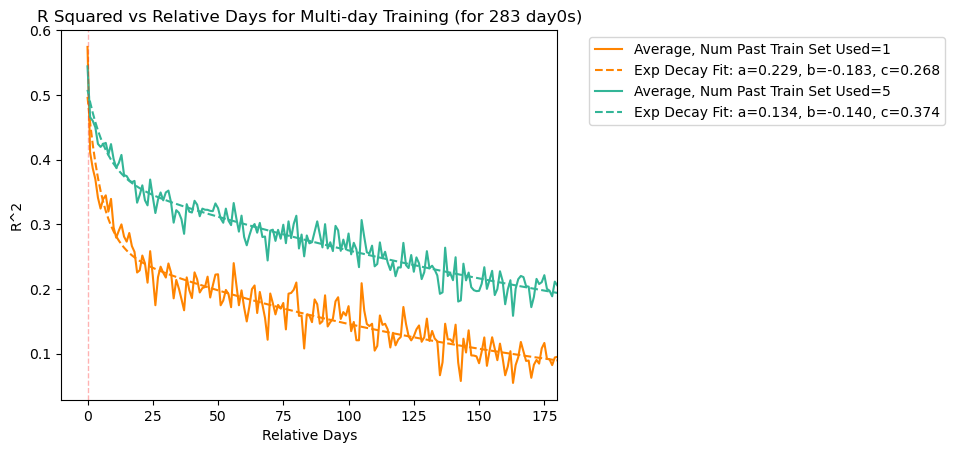

In [16]:
from scipy.optimize import curve_fit
from scipy.io import savemat

durs = [1,5]
#durs = [1,2]
colours = ['#FF8400', '#33B597']
#colours = ['darkblue', 'orange']
another_colours = ['#FF8400', '#33B597']
#another_colours = ['blue', 'yellow']
# for i, dur in enumerate(durs):
#     dur_df = df_filtered[df_filtered['train_duration'] == dur]
#     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    
    def double_exponential(x, a, b, c, d):
        return a * np.exp(b * x) + c * np.exp(d * x)

    xdata = dur_df2_sorted['relative_days'].values
    ydata = dur_df2['r2'].values
    mask = (xdata >= 0) & (xdata <= 180)
    xdata_fit = xdata[mask]
    ydata_fit = ydata[mask]
    plt.plot(xdata_fit, ydata_fit, '-', label=f'Average, Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)

    popt_exp, pcov_exp = curve_fit(double_exponential, xdata_fit, ydata_fit,p0 = [0.374185193331109,	0.00364659568830538,	0.133990533551338,	0.139937182028151], maxfev=10000)
    yfit_exp = double_exponential(xdata_fit, *popt_exp)
    plt.plot(xdata_fit, yfit_exp, '--', color=colours[i], label=f'Exp Decay Fit: a={popt_exp[0]:.3f}, b={popt_exp[1]:.3f}, c={popt_exp[2]:.3f}')
    print("Exp Decay Fit Parameters:", popt_exp)
    print("Exp Decay Fit Covariance:", pcov_exp)
    savemat(f'xdata_ydata_dur{dur}.mat', {'xdata': xdata, 'ydata': ydata})
plt.xlabel('Relative Days')
plt.ylabel('R^2')
#plt.gcf().set_size_inches(20, 60)
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha = 0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim((-10,180))
plt.savefig('multidayPlot.pdf', bbox_inches='tight')
plt.show()


Exp Decay Fit Parameters: [ 0.19391101 -1.43126374  0.37975439 -0.02107783]
Exp Decay Fit Covariance: [[ 4.04573783e-04  4.71553511e-04 -8.96218233e-05  1.29557619e-05]
 [ 4.71553511e-04  1.68887255e-01 -2.02784458e-03  2.81662243e-04]
 [-8.96218233e-05 -2.02784458e-03  9.37303613e-05 -1.35085603e-05]
 [ 1.29557619e-05  2.81662243e-04 -1.35085603e-05  2.54299672e-06]]
Exp Decay Fit Parameters: [ 0.09457689 -1.03073147  0.44776084 -0.01083174]
Exp Decay Fit Covariance: [[ 2.48596379e-04 -1.18466844e-04 -5.20266410e-05  5.98810536e-06]
 [-1.18466844e-04  1.69775973e-01 -1.69426185e-03  1.86539860e-04]
 [-5.20266410e-05 -1.69426185e-03  5.75099733e-05 -6.57444899e-06]
 [ 5.98810536e-06  1.86539860e-04 -6.57444899e-06  9.27874444e-07]]


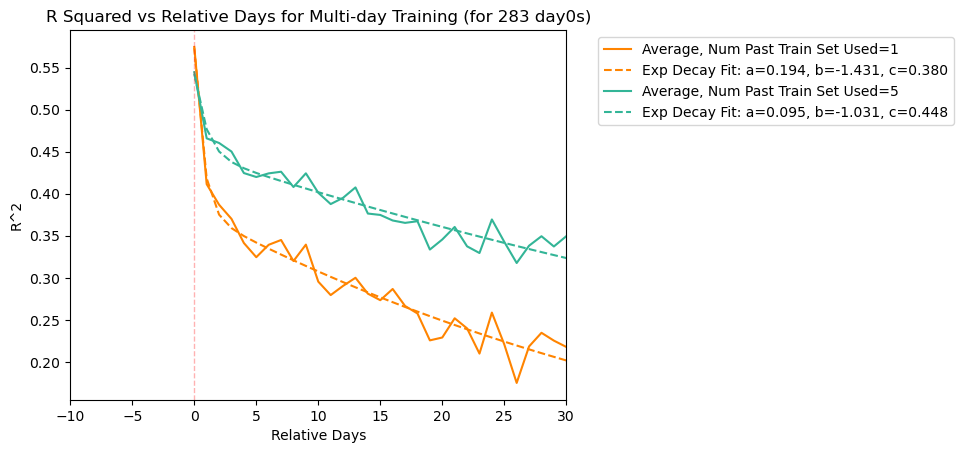

In [17]:
from scipy.optimize import curve_fit
from scipy.io import savemat

durs = [1,5]
#durs = [1,2]
colours = ['#FF8400', '#33B597']
#colours = ['darkblue', 'orange']
another_colours = ['#FF8400', '#33B597']
#another_colours = ['blue', 'yellow']
# for i, dur in enumerate(durs):
#     dur_df = df_filtered[df_filtered['train_duration'] == dur]
#     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    
    def double_exponential(x, a, b, c, d):
        return a * np.exp(b * x) + c * np.exp(d * x)

    xdata = dur_df2_sorted['relative_days'].values
    ydata = dur_df2['r2'].values
    mask = (xdata >= 0) & (xdata <= 30)
    xdata_fit = xdata[mask]
    ydata_fit = ydata[mask]
    plt.plot(xdata_fit, ydata_fit, '-', label=f'Average, Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)

    popt_exp, pcov_exp = curve_fit(double_exponential, xdata_fit, ydata_fit,p0 = [0.374185193331109,	0.00364659568830538,	0.133990533551338,	0.139937182028151], maxfev=10000)
    yfit_exp = double_exponential(xdata_fit, *popt_exp)
    plt.plot(xdata_fit, yfit_exp, '--', color=colours[i], label=f'Exp Decay Fit: a={popt_exp[0]:.3f}, b={popt_exp[1]:.3f}, c={popt_exp[2]:.3f}')
    print("Exp Decay Fit Parameters:", popt_exp)
    print("Exp Decay Fit Covariance:", pcov_exp)
    savemat(f'xdata_ydata_dur{dur}.mat', {'xdata': xdata, 'ydata': ydata})
plt.xlabel('Relative Days')
plt.ylabel('R^2')
#plt.gcf().set_size_inches(20, 60)
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha = 0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim((-10,30))
plt.savefig('multidayPlot.pdf', bbox_inches='tight')
plt.show()


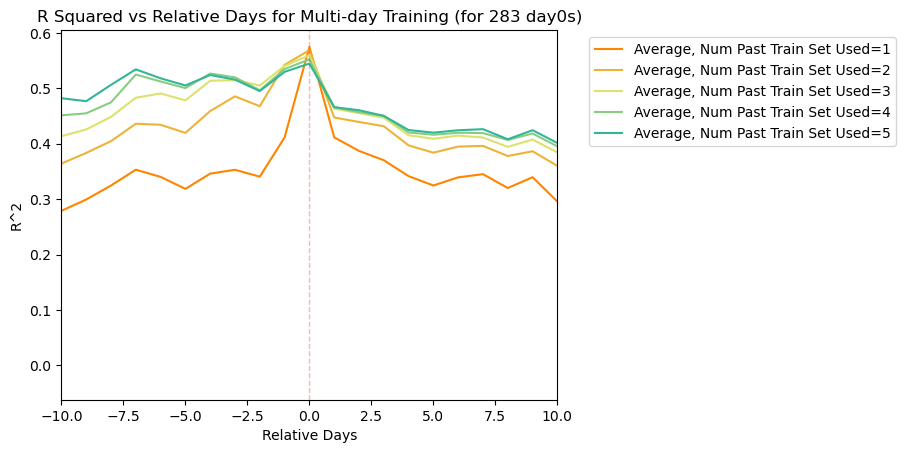

In [18]:
durs = [1,2,3,4,5]
#durs = [1,2]
colours = ['#FF8400', '#EEB336', '#DCE26B', '#88CC81', '#33B597']
#colours = ['darkblue', 'orange']
another_colours = ['#FF8400', '#EEB336', '#DCE26B', '#88CC81', '#33B597']
#another_colours = ['blue', 'yellow']
# for i, dur in enumerate(durs):
#     dur_df = df_filtered[df_filtered['train_duration'] == dur]
#     plt.plot(dur_df['relative_days'], dur_df['r2'],'.', label=f'Num Past Train Set Used={dur}', color=colours[i], alpha = 0.3)
for i, dur in enumerate(durs):
    dur_df2 = grouped_df[grouped_df['train_duration'] == dur]
    plt.plot(dur_df2_sorted['relative_days'], dur_df2['r2'], '-', label=f'Average, Num Past Train Set Used={dur}', color=another_colours[i], alpha=1.0)
plt.xlabel('Relative Days')
plt.ylabel('R^2')
#plt.gcf().set_size_inches(20, 60)
plt.title(f'R Squared vs Relative Days for Multi-day Training (for {num_train_days} day0s)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha = 0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim((-10,10))

plt.show()


Some sort of average line should be done here, however, relative days are different for different days
EITHER

1) interpolate to fill in those days
2) fit some line over these dots.